In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("C:/kaggle_customer_churn/train.csv")

In [3]:
data.sample(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
401342,401342,Female,0,Yes,Yes,25,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.6,411.25,No
184661,184661,Female,0,No,No,50,No,No phone service,DSL,No,...,No,Yes,No,No,One year,No,Electronic check,29.7,1505.80,No
258771,258771,Male,0,Yes,No,71,Yes,No,DSL,Yes,...,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),80.2,6029.00,No
298722,298722,Female,0,Yes,Yes,66,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.0,1714.95,No
60956,60956,Female,0,Yes,No,72,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.4,7711.25,No


In [4]:
data.shape

(594194, 21)

In [5]:
data.nunique()

id                  594194
gender                   2
SeniorCitizen            2
Partner                  2
Dependents               2
tenure                  72
PhoneService             2
MultipleLines            3
InternetService          3
OnlineSecurity           3
OnlineBackup             3
DeviceProtection         3
TechSupport              3
StreamingTV              3
StreamingMovies          3
Contract                 3
PaperlessBilling         2
PaymentMethod            4
MonthlyCharges        1921
TotalCharges         31910
Churn                    2
dtype: int64

In [6]:
uniques = data.nunique()
high_cardinality = uniques[uniques > 5].index.tolist()
print(high_cardinality)

['id', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [7]:
cat_data = data.select_dtypes(include = 'object')
cat_data.shape

(594194, 16)

<Axes: xlabel='count', ylabel='Churn'>

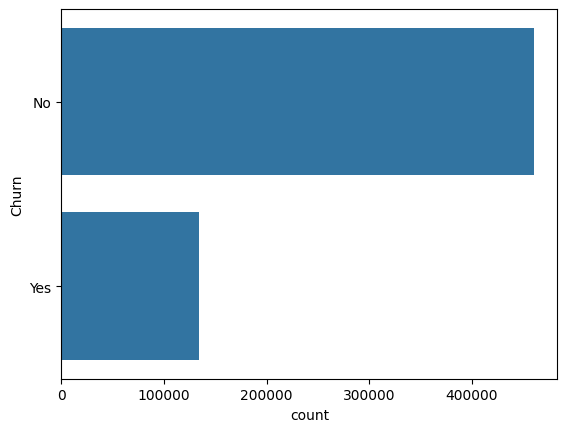

In [8]:
sns.countplot(data['Churn'])

In [9]:
data['TotalCharges'].sample(5)

486111      35.70
389031    3204.40
454496    2070.75
322162    3810.80
66330     2157.50
Name: TotalCharges, dtype: float64

In [10]:
data.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# UNIVARIATE ANALYSIS

In [11]:
num_data = data.select_dtypes(include = ['int','float64'])
num_data

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,0,29,60.10,1653.85
1,1,0,58,69.50,3778.20
2,2,0,58,100.40,5841.35
3,3,0,1,69.70,70.70
4,4,0,1,70.45,70.45
...,...,...,...,...,...
594189,594189,0,57,97.55,5460.70
594190,594190,0,72,91.95,6782.15
594191,594191,0,72,24.40,1871.90
594192,594192,0,32,86.00,2847.20


In [12]:
dummies = pd.get_dummies(data['Churn'], prefix='Churn', drop_first=True)
data = pd.concat([data, dummies], axis=1)
data.drop('Churn', axis=1, inplace=True)

In [13]:
data.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn_Yes'],
      dtype='object')

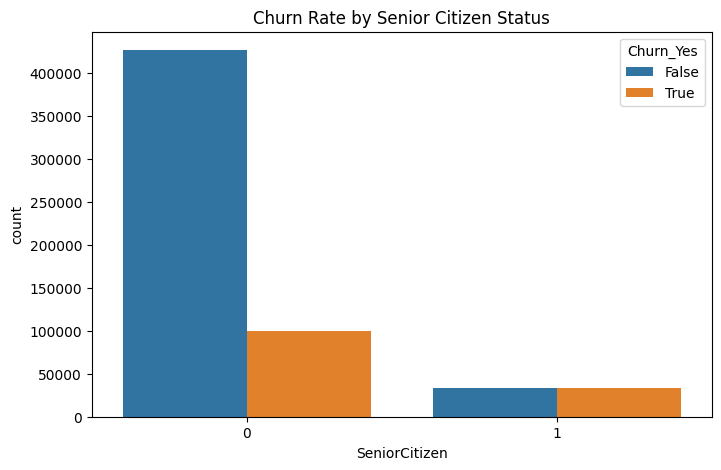

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='SeniorCitizen', hue='Churn_Yes')
plt.title('Churn Rate by Senior Citizen Status')
plt.show()